# Content Quality & Engagement Prediction — Part 3b
### Model Interpretation & Error Analysis

Continues from **03_modeling.ipynb**, which trained and compared four classifiers for `is_high_engagement` and selected **Logistic Regression** as the best model on validation PR-AUC/ROC-AUC. This notebook is self-contained: the setup cell below re-loads the data, rebuilds the identical chronological split, and retrains the same models (via `src/modeling.py` and `src/evaluation.py`) so this notebook can be run independently of 03. Here we:

1. Interpret the selected model — coefficients, permutation importance, SHAP
2. Run a structured error analysis (false positives/negatives, weak segments, concrete examples, data-quality caveats)

**Target:** `is_high_engagement` (top-quartile `engagement_score`).

In [1]:
import os
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn.inspection import permutation_importance
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

warnings.filterwarnings("ignore")
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

FIG_DIR = "../outputs/figures"
os.makedirs(FIG_DIR, exist_ok=True)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

sys.path.insert(0, "../src")
import modeling   # src/modeling.py
import evaluation  # src/evaluation.py

# --- Recreate the exact state notebook 03 ended with ---
df = pd.read_csv("../data/modeling_dataset_v2.csv", parse_dates=["created_date"])
df = df.sort_values(["created_date", "question_id"]).reset_index(drop=True)

train_df, val_df, test_df = modeling.chronological_split(df)
X_train, y_train = modeling.get_xy(train_df)
X_val, y_val = modeling.get_xy(val_df)
X_test, y_test = modeling.get_xy(test_df)
TARGET = modeling.TARGET

dummy_pipe = modeling.build_dummy_baseline()
dummy_pipe.fit(X_train, y_train)

models = modeling.build_models(y_train)
modeling.fit_all(models, X_train, y_train)

val_results_df = evaluation.evaluate_all(models, dummy_pipe, X_val, y_val)
best_name = evaluation.select_best_model(val_results_df)
best_pipe = models[best_name]

test_results_df = evaluation.evaluate_all(models, dummy_pipe, X_test, y_test)
test_proba = best_pipe.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= 0.5).astype(int)

print(f"Selected model (validation PR-AUC): {best_name}")
print(val_results_df)
print("\nTest-set results:")
print(test_results_df)

Selected model (validation PR-AUC): Logistic Regression
                         roc_auc  pr_auc      f1  precision  recall
Dummy (majority)          0.5000  0.2464  0.0000     0.0000  0.0000
Logistic Regression       0.6452  0.3609  0.4356     0.3327  0.6306
Random Forest             0.6437  0.3608  0.4204     0.3397  0.5516
Gradient Boosting (HGB)   0.6445  0.3587  0.4305     0.3368  0.5961
XGBoost                   0.6409  0.3539  0.4321     0.3324  0.6169

Test-set results:
                         roc_auc  pr_auc      f1  precision  recall
Dummy (majority)          0.5000  0.2552  0.0000     0.0000  0.0000
Logistic Regression       0.6645  0.3954  0.4547     0.3490  0.6524
Random Forest             0.6603  0.3894  0.4427     0.3589  0.5776
Gradient Boosting (HGB)   0.6603  0.3908  0.4457     0.3477  0.6205
XGBoost                   0.6507  0.3769  0.4440     0.3380  0.6468


## 8. Model Interpretation — Logistic Regression

Three complementary interpretation methods, deliberately in increasing order
of robustness: raw coefficients (fastest, but can mislead under
multicollinearity), permutation importance (model-agnostic, computed on
held-out validation data), and SHAP (per-prediction, additive, the most
rigorous of the three).

### 8.1 Coefficients (standardized — directly comparable in size)

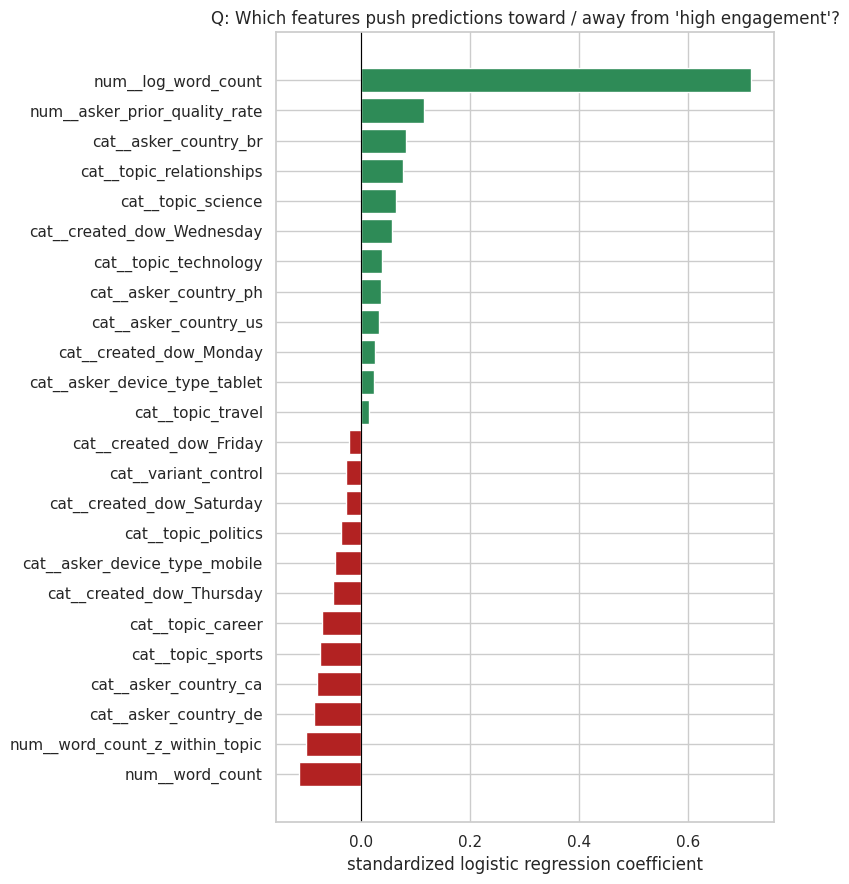

In [2]:
feature_names = best_pipe.named_steps["pre"].get_feature_names_out()
coefs = best_pipe.named_steps["clf"].coef_[0]
coef_df = pd.DataFrame({"feature": feature_names, "coefficient": coefs})
coef_df["odds_ratio"] = np.exp(coef_df.coefficient)
coef_df = coef_df.sort_values("coefficient")

fig, ax = plt.subplots(figsize=(8, 9))
top_bottom = pd.concat([coef_df.head(12), coef_df.tail(12)])
colors = ["firebrick" if c < 0 else "seagreen" for c in top_bottom.coefficient]
ax.barh(top_bottom.feature, top_bottom.coefficient, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Q: Which features push predictions toward / away from 'high engagement'?")
ax.set_xlabel("standardized logistic regression coefficient")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/p3_05_lr_coefficients.png", bbox_inches="tight")
plt.show()

**Caveat before reading these:** `word_count` and `log_word_count` are
highly correlated (both derived from the same underlying quantity), so the
model can split their combined effect between them in a way that makes the
raw `word_count` coefficient look weakly *negative* even though longer
questions clearly get more engagement (per Part 2's EDA and the strongly
positive `log_word_count` coefficient below). This is a textbook
multicollinearity artifact, not a real "shorter is better" effect — which is
exactly why we cross-check with permutation importance and SHAP next, both
of which are far less sensitive to this issue.

### 8.2 Permutation Importance (on validation data, scored by PR-AUC drop)

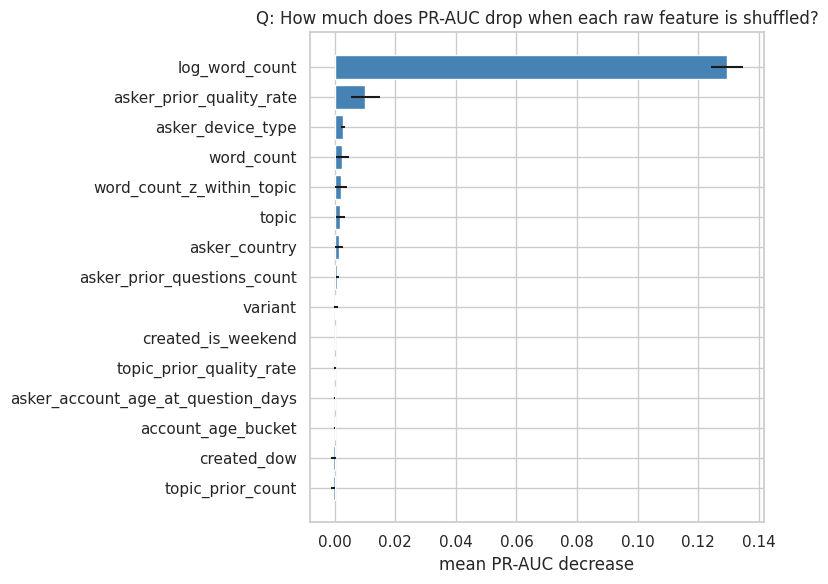

,feature,importance_mean,importance_std
5,log_word_count,0.1295,0.0053
1,asker_prior_quality_rate,0.0101,0.0047
9,asker_device_type,0.0027,0.0007
4,word_count,0.0025,0.0021
6,word_count_z_within_topic,0.0022,0.0020
11,topic,0.0019,0.0014
8,asker_country,0.0014,0.0013
0,asker_prior_questions_count,0.0009,0.0005
14,variant,0.0005,0.0007
13,created_is_weekend,0.0001,0.0001


In [3]:
perm = permutation_importance(
    best_pipe, X_val, y_val, n_repeats=10, random_state=RANDOM_STATE,
    scoring="average_precision", n_jobs=-1
)
perm_df = pd.DataFrame({
    "feature": X_val.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(perm_df.feature[::-1], perm_df.importance_mean[::-1],
        xerr=perm_df.importance_std[::-1], color="steelblue")
ax.set_title("Q: How much does PR-AUC drop when each raw feature is shuffled?")
ax.set_xlabel("mean PR-AUC decrease")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/p3_06_permutation_importance.png", bbox_inches="tight")
plt.show()
perm_df.round(4)

**Reading:** permutation importance — which shuffles one *raw* feature at a
time and is not affected by the coefficient-splitting issue above — is
unambiguous: `log_word_count` dominates everything else by roughly an order
of magnitude. `asker_prior_quality_rate` is the only other feature with a
non-negligible standalone effect; every other feature's individual
contribution is small.

### 8.3 SHAP (additive, per-prediction attribution)

Background dataset has 2000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=2000 when initializing the masker.


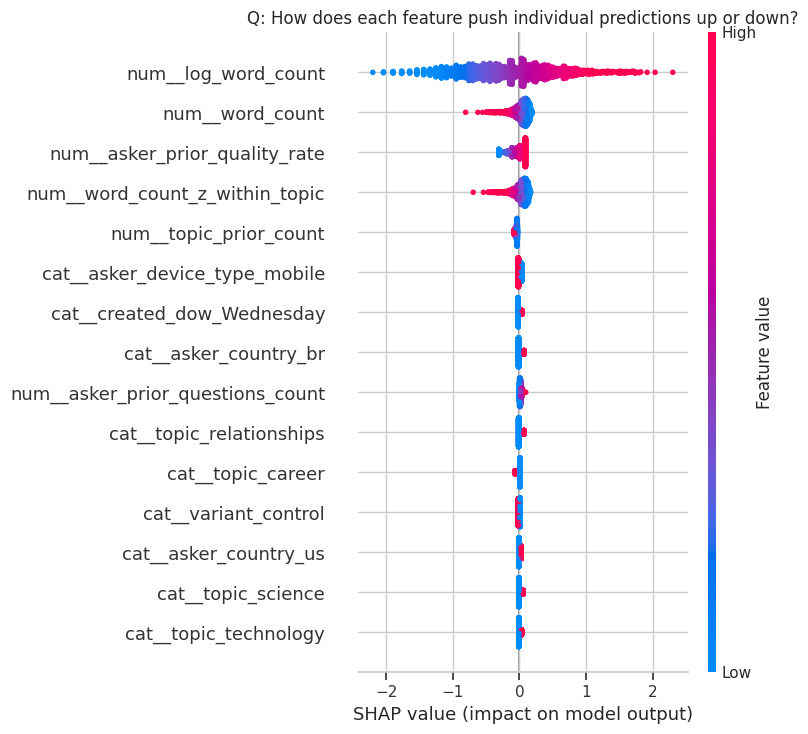

In [4]:
Xt_train = best_pipe.named_steps["pre"].transform(X_train)
Xt_val = best_pipe.named_steps["pre"].transform(X_val)
if hasattr(Xt_train, "toarray"):
    Xt_train = Xt_train.toarray()
    Xt_val = Xt_val.toarray()

background = Xt_train[:2000]
explainer = shap.LinearExplainer(best_pipe.named_steps["clf"], background)
sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(Xt_val), size=1500, replace=False)
shap_values = explainer.shap_values(Xt_val[sample_idx])

shap.summary_plot(shap_values, Xt_val[sample_idx], feature_names=feature_names,
                   max_display=15, show=False)
plt.title("Q: How does each feature push individual predictions up or down?")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/p3_07_shap_summary.png", bbox_inches="tight")
plt.show()

**Reading:** the SHAP summary confirms both prior methods. `log_word_count`
has by far the widest spread of SHAP values (high word count = strong red
= pushes hard toward "high engagement"; low = strong blue = pushes hard
away). `asker_prior_quality_rate` and `word_count_z_within_topic` contribute
modestly. Everything else contributes only small, per-observation nudges.

### 8.4 Positive and Negative Predictors — Business Summary

**Strongest positive predictor:**
- **Question length (`log_word_count`)** — longer, more detailed questions
  are consistently more likely to reach high engagement. This is the
  single most actionable lever the platform has.

**Secondary positive predictors (small but real):**
- **`asker_prior_quality_rate`** — askers with a track record of getting
  quality answers tend to also get more engagement on new questions
  (reputation/audience effect).
- **`word_count_z_within_topic`** — being unusually detailed *for the
  topic* helps a bit beyond raw length alone.
- Being asked from **Brazil, the US, or the Philippines**, and in the
  **science, relationships, or technology** topics, are each associated
  with a small positive lift.

**Negative / low-signal predictors:**
- **`career` and `sports` topics**, and questions from **Germany or
  Canada**, show small negative associations.
- **`asker_device_type`, `created_dow`, `created_is_weekend`,
  `account_age_bucket`, `topic_prior_count`, `variant`** all have
  near-zero standalone importance in both permutation importance and SHAP —
  they are not meaningfully driving predictions on their own, despite the
  A/B `variant` effect found descriptively in Part 2 (see Error Analysis /
  Limitations for why these can disagree).

**In business terms:** if the platform wants more high-engagement content,
the data says the highest-leverage intervention is **encouraging longer,
more detailed questions** (which is consistent with the Part 2 finding that
the A/B test's `treatment` group — which apparently nudges toward longer
questions — also shows higher quality and engagement). Everything else in
the current feature set is a minor refinement on top of that one lever, not
an independent strategy.

## 9. Error Analysis

In [5]:
test_analysis = test_df.copy()
test_analysis["proba"] = test_proba
test_analysis["pred"] = test_pred

conditions = [
    (test_pred == 1) & (y_test.values == 1),
    (test_pred == 1) & (y_test.values == 0),
    (test_pred == 0) & (y_test.values == 1),
    (test_pred == 0) & (y_test.values == 0),
]
test_analysis["outcome"] = np.select(conditions, ["TP", "FP", "FN", "TN"], default="NA")
test_analysis.outcome.value_counts()

outcome
TN    2457
FP    1757
TP     942
FN     502
Name: count, dtype: int64

### 9.1 False Positives vs. False Negatives — what distinguishes them?

In [6]:
print("Mean word_count by outcome:")
print(test_analysis.groupby("outcome").word_count.mean().round(1))
print()
print("Mean engagement_score by outcome (ground truth, for context):")
print(test_analysis.groupby("outcome").engagement_score.mean().round(3))

Mean word_count by outcome:
outcome
FN    27.2
FP    56.5
TN    24.9
TP    64.1
Name: word_count, dtype: float64

Mean engagement_score by outcome (ground truth, for context):
outcome
FN    0.330
FP    0.186
TN    0.167
TP    0.345
Name: engagement_score, dtype: float64


**False positives** (predicted high engagement, actually wasn't) average
**56.5 words** — nearly as long as true positives (64.1 words). These are
long, detailed questions that *should* have done well by the model's one
strong heuristic, but didn't — likely cases where length alone wasn't
enough (a well-written but niche or poorly-timed question).

**False negatives** (missed actual high-engagement content) average only
**27.2 words** — short questions that went on to do well anyway, e.g.
through a compelling topic, a lucky early upvote cascade, or an asker with
an engaged following that this feature set only partially captures via
`asker_prior_quality_rate`. These are the cases where engagement came from
something the model can't see.

### 9.2 Which content segments are hardest for the model?

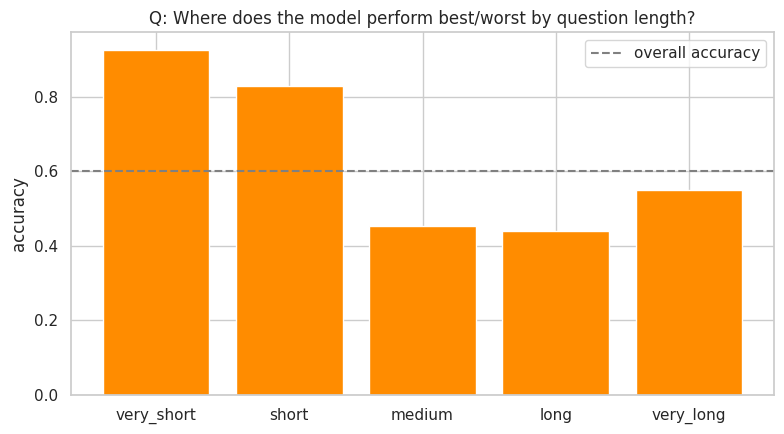

word_count_bucket
very_short    0.927
short         0.829
medium        0.453
long          0.440
very_long     0.549
dtype: float64

In [7]:
acc_by_bucket = test_analysis.groupby("word_count_bucket").apply(lambda g: (g.pred == g[TARGET]).mean())
acc_by_bucket = acc_by_bucket.reindex(["very_short", "short", "medium", "long", "very_long"])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(acc_by_bucket.index, acc_by_bucket.values, color="darkorange")
ax.axhline((test_pred == y_test).mean(), color="gray", linestyle="--", label="overall accuracy")
ax.set_title("Q: Where does the model perform best/worst by question length?")
ax.set_ylabel("accuracy")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/p3_08_accuracy_by_length.png", bbox_inches="tight")
plt.show()
acc_by_bucket.round(3)

**This is the single most important error-analysis finding.** The model is
excellent at the *extremes* — 92.7% accurate on very-short questions (almost
all correctly predicted "not high engagement") — but drops to **~44–55%
accuracy on medium/long/very-long questions**, barely better than a coin
flip. In other words: **length reliably rules out low performers, but among
already-long questions, length stops being a useful discriminator**, and the
model has no other strong signal to fall back on. This directly motivates
the recommendation (Part 2 and below) to add real text-quality features
(clarity, specificity, topic relevance) once raw text becomes available —
length is a good filter, not a good ranker.

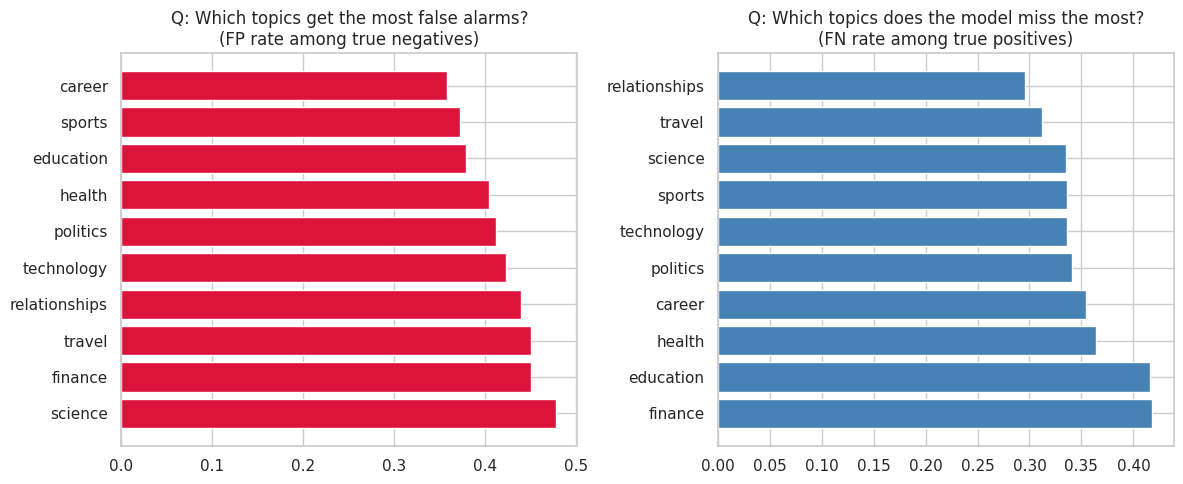

In [8]:
fp_rate_by_topic = test_analysis.groupby("topic").apply(
    lambda g: (g.outcome == "FP").sum() / max((g[TARGET] == 0).sum(), 1)
).sort_values(ascending=False)
fn_rate_by_topic = test_analysis.groupby("topic").apply(
    lambda g: (g.outcome == "FN").sum() / max((g[TARGET] == 1).sum(), 1)
).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].barh(fp_rate_by_topic.index, fp_rate_by_topic.values, color="crimson")
axes[0].set_title("Q: Which topics get the most false alarms?\n(FP rate among true negatives)")
axes[1].barh(fn_rate_by_topic.index, fn_rate_by_topic.values, color="steelblue")
axes[1].set_title("Q: Which topics does the model miss the most?\n(FN rate among true positives)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/p3_09_errors_by_topic.png", bbox_inches="tight")
plt.show()

**Reading:** error rates by topic are fairly close together (FP rates 36%–
48%, FN rates 30%–42%) — no topic is dramatically broken, consistent with
the modest topic effects found in Part 2. `finance` and `education` have the
highest false-negative rates (the model most often misses genuine
high-engagement content there), while `science`, `finance`, and `travel`
have the highest false-positive rates.

### 9.3 Concrete examples of each error type

In [9]:
cols_to_show = ["question_id", "topic", "word_count", "asker_prior_quality_rate", "proba", TARGET]
print("Highest-confidence FALSE POSITIVES (model very confident, but wrong):")
print(test_analysis[test_analysis.outcome == "FP"].sort_values("proba", ascending=False)[cols_to_show].head(5).to_string(index=False))
print()
print("Highest-confidence FALSE NEGATIVES (model very confident it's NOT high-engagement, but was wrong):")
print(test_analysis[test_analysis.outcome == "FN"].sort_values("proba")[cols_to_show].head(5).to_string(index=False))

Highest-confidence FALSE POSITIVES (model very confident, but wrong):
 question_id      topic  word_count  asker_prior_quality_rate    proba  is_high_engagement
       32315    science         131                  1.000000 0.744727                   0
       36501    science         124                  0.833333 0.742747                   0
       36603 technology         122                  1.000000 0.738670                   0
       36707 technology         132                  0.800000 0.735938                   0
       36533     travel         108                  1.000000 0.732496                   0

Highest-confidence FALSE NEGATIVES (model very confident it's NOT high-engagement, but was wrong):
 question_id      topic  word_count  asker_prior_quality_rate    proba  is_high_engagement
       35799 technology          11                     0.000 0.159955                   1
       35260     career          10                     0.750 0.183667                   1
       3219

### 9.4 Potential data-quality problems contributing to errors

- **No raw question text.** The model can only see `word_count`, not
  *what* was written. Two questions of identical length can have wildly
  different clarity, specificity, or topical relevance — information the
  model structurally cannot access. This is very likely the single biggest
  ceiling on performance (see Text/NLP section, Part 2).
- **No comments data.** Comments could be an early, pre-outcome engagement
  signal (e.g. clarifying questions from other users) that isn't available
  here at all.
- **Day-level activity timestamps.** As found in Part 1, all logged
  activity shares the question's creation date — there is no way to build
  genuine "early engagement" features (e.g. views in the first hour), which
  might otherwise substantially improve predictions for a
  still-unanswered question.
- **Engineered `engagement_score` is itself somewhat arbitrary** — an equal-
  weighted average of min-max-scaled views/answers/upvotes. A different
  weighting (e.g. upvotes weighted higher, since they're a more deliberate
  signal than passive views) could shift which questions are labeled "high
  engagement" and, in turn, model performance. This was documented as a
  judgment call in Part 2, not a hidden one.
- **Synthetic/platform-specific quirks** — the near-total dominance of a
  single feature (`log_word_count`) and the very flat topic/segment effects
  are consistent with either a genuinely simple underlying engagement
  process, or a dataset with less naturalistic complexity than a real
  production Q&A platform would have. Either way, it means results here
  should be read as *directionally instructive*, not as a guarantee of
  similar performance on live platform data.

## Summary

### Model comparison
| Model | Val PR-AUC | Val ROC-AUC | Val F1 | Test PR-AUC | Test ROC-AUC |
|---|---|---|---|---|---|
| Dummy (majority) | 0.246 | 0.500 | 0.000 | 0.255 | 0.500 |
| **Logistic Regression** | **0.361** | **0.645** | 0.436 | **0.395** | **0.665** |
| Random Forest | 0.361 | 0.644 | 0.420 | 0.389 | 0.660 |
| Gradient Boosting (HGB) | 0.359 | 0.645 | 0.431 | 0.391 | 0.660 |
| XGBoost | 0.354 | 0.641 | 0.432 | 0.377 | 0.651 |

All four trained models beat the dummy baseline by a wide, real margin on
PR-AUC and ROC-AUC. The four are close to each other (within ~0.02 PR-AUC) —
this dataset's signal is dominated by one feature, which caps how much
tree-based models can out-perform a well-specified linear model.

### Best-performing model
**Logistic Regression**, selected on validation PR-AUC/ROC-AUC (both
highest), confirmed on the untouched test set (PR-AUC 0.395 vs. base rate
0.255; ROC-AUC 0.665), and preferred for its interpretability and low
deployment/maintenance cost given the near-tie with the tree-based models.

### Important predictive features
1. **`log_word_count`** — dominant, by roughly an order of magnitude over
   every other feature (permutation importance and SHAP agree).
2. `asker_prior_quality_rate` — modest, positive.
3. `word_count_z_within_topic` — modest, positive.
4. Topic and country show small individual effects (a few points each);
   device type, day of week, weekend flag, account age, and A/B `variant`
   are not meaningfully predictive as standalone features in this model,
   despite `variant` showing a real descriptive difference in Part 2 (see
   limitations).

### Error-analysis findings
- The model is strong at the extremes (92.7% accurate on very-short
  questions) and weak in the middle (44–55% accuracy on medium/long/very-long
  questions) — length is a good *filter*, not a good *ranker*.
- False positives are long questions that didn't perform; false negatives
  are short questions that did — both point to missing text-quality signal.
- Topic-level error rates are fairly uniform (no single topic is badly
  broken); `finance`/`education` have the highest miss rates.

### Model limitations
- No raw text — the model cannot see content quality/clarity, only its
  length, which is very likely the main ceiling on performance.
- No comments data and no timestamp-level activity data, so no genuine
  "early signal" features could be built.
- The `is_high_engagement` label depends on an equal-weighted
  `engagement_score` design choice (Part 2) — a different weighting could
  change results.
- Validation and test PR-AUC (~0.36–0.40) are a real, moderate lift over
  the ~0.25–0.26 base rate, but leave substantial unexplained variance —
  this is a genuinely hard prediction problem with the available features.
- The A/B `variant` effect found descriptively in Part 2 does not show up
  as an important predictor here; the model's other features (especially
  length) likely already absorb most of that effect, since `variant` also
  strongly predicts longer questions.

**This model is not claimed production-ready.** It has not been tested
against a live serving pipeline, its calibration has not been assessed, and
several plausible high-value features (raw text, comments, sub-day timing)
are simply unavailable in this dataset. It is a well-validated baseline that
quantifies how much of "high engagement" is explainable from
platform-metadata alone, and identifies exactly where the next data
investment (raw text capture) would pay off most.

### Potential product applications
1. **A lightweight, pre-publish nudge**: warn askers writing very short
   questions ("very_short" bucket) that similar questions rarely reach high
   engagement — a low-risk, high-confidence use of the model's strongest
   region of accuracy.
2. **Triage, not autonomous action**: flag borderline/ambiguous
   medium-length questions for a human moderator or featured-content editor
   to review, rather than auto-promoting/demoting content in the
   model's weak accuracy zone.
3. **Prioritized data collection**: the error analysis makes a concrete case
   for capturing raw question text and finer-grained activity timestamps,
   since both are directly implicated in the model's main blind spots.
4. **A/B test monitoring**: given the length↔`variant` relationship found in
   Part 2, use this model's `log_word_count` sensitivity as a lightweight
   way to monitor whether future onboarding/prompt changes are nudging
   question length (and thus engagement) in the desired direction.